In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import seaborn as sns
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import os
from sklearn.preprocessing import RobustScaler


In [14]:
#Ruta al directorio base y del archivo Silver
BASE_DIR = os.path.abspath(os.path.join(os.path.dirname('__file__'), "..", ".."))
SILVER_DIR = os.path.join(BASE_DIR, "data", "capa_silver")
SILVER_FILE_PATH = os.path.join(SILVER_DIR, "silver_data.parquet")
VARIABLES_CONTINUAS = [
    "voltaje",
    "corriente_carga",
    "temperatura_aceite",
    "temperatura_aceite_OLTC",
    "temperatura_ambiente",
    "temperatura_punto_caliente",
    "temperatura_burbujeo",
    "potencia_aparente",
]
VARIABLES_DISCRETAS = [
    "tap_position"
]

# Cargar el dataset Silver
try:
    df_gold = pd.read_parquet(SILVER_FILE_PATH)
    print(f"Dimensiones del DataFrame: {df_gold.shape}")
    print(display(df_gold.head()))
    print("\nInformacion del DataFrame:")
    df_gold.info()
except Exception as e:
    print(f"Ocurrio un error al cargar los datos Silver: {e}")

Dimensiones del DataFrame: (30912, 9)


,voltaje,corriente_carga,temperatura_aceite,temperatura_aceite_OLTC,temperatura_ambiente,temperatura_punto_caliente,temperatura_burbujeo,potencia_aparente,tap_position
timestamp,,,,,,,,,
2024-09-10 04:00:00,131.041825,739.327177,51.534286,47.685000,26.500000,56.185879,178.928398,30.745757,10
2024-09-10 04:15:00,130.693073,728.593612,53.500000,49.825000,26.650000,58.642727,178.854984,30.232734,11
2024-09-10 04:30:00,130.812457,715.310359,53.342857,50.025000,26.800000,58.308074,178.781570,29.725678,11
2024-09-10 04:45:00,130.924854,701.814300,53.185714,49.739999,26.600000,57.973421,178.411140,29.164683,11
2024-09-10 05:00:00,130.564417,688.681148,53.028571,48.650999,26.233334,57.638768,176.250397,28.610652,11


None

Informacion del DataFrame:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 30912 entries, 2024-09-10 04:00:00 to 2025-07-29 03:45:00
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   voltaje                     30912 non-null  float64
 1   corriente_carga             30912 non-null  float64
 2   temperatura_aceite          30912 non-null  float64
 3   temperatura_aceite_OLTC     30912 non-null  float64
 4   temperatura_ambiente        30912 non-null  float64
 5   temperatura_punto_caliente  30912 non-null  float64
 6   temperatura_burbujeo        30912 non-null  float64
 7   potencia_aparente           30912 non-null  float64
 8   tap_position                30912 non-null  int64  
dtypes: float64(8), int64(1)
memory usage: 2.4 MB


In [15]:
import numpy as np
import pandas as pd
from scipy import stats

class BoxCoxTransformer:
    """
    Aplica Box–Cox a columnas continuas y positivas.
    - Si la columna tiene valores <= 0, aplica un shift: x' = x + |min| + eps.
    - Guarda lambda y shift por columna para poder invertir.
    """

    def __init__(self, eps=1e-6):
        self.eps = eps
        self.lambdas_ = {}  # {col: lambda}
        self.shifts_  = {}  # {col: shift añadido}

    def fit_transform(self, df: pd.DataFrame, cols: list) -> pd.DataFrame:
        df_out = df.copy()
        for col in cols:
            x = df_out[col].astype(float).to_numpy()

            # Shift si hay valores <= 0
            shift = 0.0
            x_min = np.nanmin(x)
            if not np.isfinite(x_min):
                raise ValueError(f"{col}: todos los valores son NaN/inf; revise la columna.")
            if x_min <= 0:
                shift = -x_min + self.eps
                x = x + shift

            # Relleno temporal de NaNs para el ajuste del lambda (Box-Cox no admite NaN)
            # Usamos media de la serie (solo para el ajuste); luego reponemos NaN en el resultado.
            nan_mask = np.isnan(x)
            if nan_mask.any():
                mean_val = np.nanmean(x)
                x_for_fit = x.copy()
                x_for_fit[nan_mask] = mean_val
            else:
                x_for_fit = x

            # Ajuste y transformación
            x_bc, lam = stats.boxcox(x_for_fit)
            # Reponer NaNs en las posiciones originales
            x_bc[nan_mask] = np.nan

            # Persistir en el DataFrame
            df_out[col] = x_bc

            # Guardar parámetros
            self.lambdas_[col] = lam
            self.shifts_[col]  = shift

        return df_out

    def inverse_transform(self, df: pd.DataFrame, cols: list) -> pd.DataFrame:
        df_inv = df.copy()
        for col in cols:
            if col not in self.lambdas_:
                raise ValueError(f"No hay lambda para la columna '{col}'. Ejecute fit_transform primero.")
            lam   = self.lambdas_[col]
            shift = self.shifts_.get(col, 0.0)

            y = df_inv[col].astype(float).to_numpy()
            nan_mask = np.isnan(y)

            # Inversa de Box–Cox:  y = (lam * x_bc + 1) ** (1/lam)  si lam != 0
            #                       exp(x_bc)                      si lam == 0
            if lam == 0:
                x = np.exp(y)
            else:
                x = np.power(lam * y + 1.0, 1.0 / lam)

            # Quitar shift
            x = x - shift
            x[nan_mask] = np.nan
            df_inv[col] = x
        return df_inv

    def report_skew_kurt(self, df_before: pd.DataFrame, df_after: pd.DataFrame, cols: list) -> pd.DataFrame:
        rows = []
        for col in cols:
            b = df_before[col].dropna().astype(float)
            a = df_after[col].dropna().astype(float)
            rows.append({
                "columna": col,
                "lambda": self.lambdas_.get(col),
                "shift":  self.shifts_.get(col, 0.0),
                "skew_before": stats.skew(b),
                "kurt_before": stats.kurtosis(b),
                "skew_after":  stats.skew(a),
                "kurt_after":  stats.kurtosis(a),
            })
        return pd.DataFrame(rows)


In [16]:
# columnas a transformar según tu análisis
cols_bc = ["corriente_carga", "temperatura_burbujeo","potencia_aparente"]

# 1) Ajuste + transformación
bc = BoxCoxTransformer(eps=1e-6)
df_gold_bc = bc.fit_transform(df_gold, cols_bc)

# 2) Validación estadística
reporte = bc.report_skew_kurt(df_gold, df_gold_bc, cols_bc)
print(reporte)


                columna    lambda     shift  skew_before  kurt_before  \
0       corriente_carga  0.907248  0.000001     0.156357     0.517290   
1  temperatura_burbujeo  0.931318  0.000000     0.027099     0.658700   
2     potencia_aparente  0.699280  0.000000     0.360123     0.461319   

   skew_after  kurt_after  
0    0.044767    0.568454  
1    0.013580    0.715418  
2    0.038801    0.521966  


In [ ]:
df_copy=df_gold_bc.copy()
df_copy["gradiente_termico"] = df_copy["temperatura_aceite"] - df_copy["temperatura_ambiente"]
df_copy["hour"] = df_copy.index.hour
df_copy["dia_semana"] = df_copy.index.dayofweek
df_copy["mes"] = df_copy.index.month
df_copy["is_weekend"] = (df_copy.index.dayofweek >= 5).astype(int)


In [ ]:
df_copy.dropna(inplace=True) 

In [24]:
cols_to_drop_for_multicollinearity = [
    'corriente_carga',  # Alta correlación con corriente_carga
    'temperatura_aceite',
    'temperatura_aceite_OLTC',
    'temperatura_burbujeo'
]

# Asegurarse de que las columnas existan antes de intentar eliminarlas
existing_cols_to_drop = [col for col in cols_to_drop_for_multicollinearity if col in df_copy.columns]

df_copy = df_copy.drop(columns=existing_cols_to_drop)
print(f"Columnas eliminadas por multicolinealidad: {existing_cols_to_drop}")
print(display(df_copy.head()))

Columnas eliminadas por multicolinealidad: ['corriente_carga', 'temperatura_aceite', 'temperatura_aceite_OLTC', 'temperatura_burbujeo']


,voltaje,temperatura_ambiente,temperatura_punto_caliente,potencia_aparente,tap_position,gradiente_termico,hour,dia_semana,mes,is_weekend
timestamp,,,,,,,,,,
2024-09-10 04:00:00,131.041825,26.500000,56.185879,14.263727,10,25.034286,4,1,9,0
2024-09-10 04:15:00,130.693073,26.650000,58.642727,14.080147,11,26.850000,4,1,9,0
2024-09-10 04:30:00,130.812457,26.800000,58.308074,13.897779,11,26.542857,4,1,9,0
2024-09-10 04:45:00,130.924854,26.600000,57.973421,13.694917,11,26.585714,4,1,9,0
2024-09-10 05:00:00,130.564417,26.233334,57.638768,13.493419,11,26.795238,5,1,9,0


None


In [25]:
total_len = len(df_copy)
train_start = int(total_len * 0.4)
train_end = int(total_len * 0.6)

# X_train: 20% del medio
df_test = df_copy[train_start:train_end]

# X_test: 40% del inicio + 40% del final
df_train = pd.concat([df_copy[:train_start], df_copy[train_end:]], axis=0)

print(f"Datos de entrenamiento: {df_train.shape}")
print(f"Datos de prueba: {df_test.shape}")


Datos de entrenamiento: (24729, 10)
Datos de prueba: (6183, 10)


In [26]:
def aplicar_robust_scaler_train_test(df_train, df_test, columnas):
    scaler = RobustScaler()
    
    # Entrenar el scaler SOLO con datos de entrenamiento
    scaler.fit(df_train[columnas])
    
    # Aplicar transformación a ambos conjuntos
    df_train_scaled = df_train.copy()
    df_test_scaled = df_test.copy()
    
    df_train_scaled[columnas] = scaler.transform(df_train[columnas])
    df_test_scaled[columnas] = scaler.transform(df_test[columnas])
    
    return df_train_scaled, df_test_scaled, scaler

# Aplicar escalado
columnas_a_escalar = [
    'voltaje',
    'temperatura_ambiente', 'temperatura_punto_caliente',
 'potencia_aparente', 'gradiente_termico', 'hour', 'dia_semana', 'mes', 'is_weekend'
]

df_train_scaled, df_test_scaled, scaler = aplicar_robust_scaler_train_test(
    df_train, df_test, columnas_a_escalar
)

print("Datos de entrenamiento escalados:")
print(df_train_scaled[columnas_a_escalar].head())
print("\nDatos de prueba escalados:")
print(df_test_scaled[columnas_a_escalar].head())

# Verificar que las escalas son consistentes
print(f"\nEstadísticas del conjunto de entrenamiento escalado:")
print(df_train_scaled[columnas_a_escalar].describe())
print(f"\nEstadísticas del conjunto de prueba escalado:")
print(df_test_scaled[columnas_a_escalar].describe())

Datos de entrenamiento escalados:
                      voltaje  temperatura_ambiente  \
timestamp                                             
2024-09-10 04:00:00  0.245521              0.331338   
2024-09-10 04:15:00  0.127349              0.348477   
2024-09-10 04:30:00  0.167801              0.365615   
2024-09-10 04:45:00  0.205886              0.342764   
2024-09-10 05:00:00  0.083755              0.300870   

                     temperatura_punto_caliente  potencia_aparente  \
timestamp                                                            
2024-09-10 04:00:00                    0.572902           0.490691   
2024-09-10 04:15:00                    0.786503           0.425153   
2024-09-10 04:30:00                    0.757408           0.360048   
2024-09-10 04:45:00                    0.728313           0.287627   
2024-09-10 05:00:00                    0.699218           0.215692   

                     gradiente_termico      hour  dia_semana  mes  is_weekend  
timestamp

In [27]:
X_train = df_train_scaled.drop(columns=['temperatura_punto_caliente'])
y_train = df_train_scaled['temperatura_punto_caliente']
X_test = df_test_scaled.drop(columns=['temperatura_punto_caliente'])
y_test = df_test_scaled['temperatura_punto_caliente']

In [28]:
from xgboost import XGBRegressor
import xgboost as xgb

estimators = 200

# Crear el modelo XGBoost para regresión
params = { 
    "n_estimators":estimators,
    "learning_rate":0.05,
    "gamma": 0.3,
    "min_child_weight": 5,
    "max_depth": 2,
    "subsample": 0.7,
    "colsample_bytree": 0.9,
    "objective": 'reg:squarederror',
    "random_state": 42,
    "n_jobs": 3
}

model = xgb.XGBRegressor(**params)
# Ver la configuración por defecto
print(model.get_params())


{'objective': 'reg:squarederror', 'base_score': None, 'booster': None, 'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None, 'colsample_bytree': 0.9, 'device': None, 'early_stopping_rounds': None, 'enable_categorical': False, 'eval_metric': None, 'feature_types': None, 'feature_weights': None, 'gamma': 0.3, 'grow_policy': None, 'importance_type': None, 'interaction_constraints': None, 'learning_rate': 0.05, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None, 'max_delta_step': None, 'max_depth': 2, 'max_leaves': None, 'min_child_weight': 5, 'missing': nan, 'monotone_constraints': None, 'multi_strategy': None, 'n_estimators': 200, 'n_jobs': 3, 'num_parallel_tree': None, 'random_state': 42, 'reg_alpha': None, 'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None, 'subsample': 0.7, 'tree_method': None, 'validate_parameters': None, 'verbosity': None}


In [29]:
def train_and_evaluate_xgboost(model, X_train, y_train, X_test, y_test, max_estimators=200):
    """
    Entrena un modelo XGBoost variando el número de estimadores y guarda las métricas.

    Retorna:
    - train_losses: lista con las pérdidas de entrenamiento
    - test_losses: lista con las pérdidas de prueba
    - test_accuracies: lista con las precisiones de prueba (R² en regresión)
    """
    train_accuracies = []
    train_losses = []
    test_losses = []
    test_accuracies = []

    for n_estimators in range(1, max_estimators + 1):
        model.set_params(n_estimators=n_estimators)
        model.fit(X_train, y_train)

        # Predicciones
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        # Calcular métricas
        train_accuracy = r2_score(y_train, y_train_pred)
        train_loss = mean_absolute_error(y_train, y_train_pred)
        test_loss = mean_absolute_error(y_test, y_test_pred)
        test_accuracy = r2_score(y_test, y_test_pred)

        # Guardar métricas
        train_accuracies.append(train_accuracy)
        train_losses.append(train_loss)
        test_losses.append(test_loss)
        test_accuracies.append(test_accuracy)

        # Imprimir progreso
        print(f"Estimators: {n_estimators}/{max_estimators}.. Tr MAE: {train_loss:.3f}.. Test MAE: {test_loss:.3f}.. tr R²: {train_accuracy:.3f}.. Test R²: {test_accuracy:.3f}")

    return train_losses, test_losses, test_accuracies, train_accuracies

def plot_training_metrics(train_losses, test_losses, test_accuracies, train_accuracies, max_estimators=200):
    """
    Grafica las métricas de entrenamiento y prueba obtenidas.

    """

    plt.figure(figsize=(8, 3))

    # Gráfica de pérdida
    plt.subplot(1, 2, 1)
    plt.plot(range(1, max_estimators + 1), train_losses, label='Training Loss')
    plt.plot(range(1, max_estimators + 1), test_losses, label='Test Loss')
    plt.xlabel("Estimators")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Training and Test Loss")

    # Gráfica de precisión (R²)
    plt.subplot(1, 2, 2)
    plt.plot(range(1, max_estimators + 1), test_accuracies, label='Test Accuracy (R²)', color='orange')
    plt.plot(range(1, max_estimators + 1), train_accuracies, label='Test Accuracy (R²)', color='blue')
    plt.xlabel("Estimators")
    plt.ylabel("Accuracy (R²)")
    plt.legend()
    plt.title("Test Accuracy (R²)")

    plt.tight_layout()
    plt.show()

def plot_test_predictions(y_test, y_test_pred):
    """
    Grafica las predicciones vs valores reales y los residuos en el conjunto de prueba.

    """

    # Gráfico de dispersión: Predicciones vs Valores Reales
    plt.figure(figsize=(8, 3))
    plt.scatter(y_test, y_test_pred, color='blue', alpha=0.5)
    plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Ideal (y = x)')
    plt.xlabel("Real Values")
    plt.ylabel("Predicted Values")
    plt.title("Predictions vs Real Values (Test Set)")
    plt.legend()
    plt.show()

    # Gráfico de residuos
    residuals = y_test - y_test_pred
    plt.figure(figsize=(8, 4))
    plt.scatter(y_test, residuals, color='green', alpha=0.5)
    plt.axhline(y=0, color='red', linestyle='--')
    plt.xlabel("Real Values")
    plt.ylabel("Residuals (Error)")
    plt.title("Residuals vs Real Values (Test Set)")
    plt.show()

Estimators: 1/200.. Tr MAE: 0.571.. Test MAE: 0.808.. tr R²: 0.072.. Test R²: -0.787
Estimators: 2/200.. Tr MAE: 0.549.. Test MAE: 0.773.. tr R²: 0.136.. Test R²: -0.647
Estimators: 3/200.. Tr MAE: 0.529.. Test MAE: 0.738.. tr R²: 0.195.. Test R²: -0.509
Estimators: 4/200.. Tr MAE: 0.509.. Test MAE: 0.705.. tr R²: 0.248.. Test R²: -0.392
Estimators: 5/200.. Tr MAE: 0.491.. Test MAE: 0.676.. tr R²: 0.298.. Test R²: -0.295
Estimators: 6/200.. Tr MAE: 0.474.. Test MAE: 0.647.. tr R²: 0.342.. Test R²: -0.192
Estimators: 7/200.. Tr MAE: 0.458.. Test MAE: 0.619.. tr R²: 0.382.. Test R²: -0.097
Estimators: 8/200.. Tr MAE: 0.443.. Test MAE: 0.593.. tr R²: 0.419.. Test R²: -0.019
Estimators: 9/200.. Tr MAE: 0.428.. Test MAE: 0.570.. tr R²: 0.454.. Test R²: 0.045
Estimators: 10/200.. Tr MAE: 0.415.. Test MAE: 0.545.. tr R²: 0.485.. Test R²: 0.123
Estimators: 11/200.. Tr MAE: 0.405.. Test MAE: 0.521.. tr R²: 0.512.. Test R²: 0.197
Estimators: 12/200.. Tr MAE: 0.391.. Test MAE: 0.501.. tr R²: 0.54

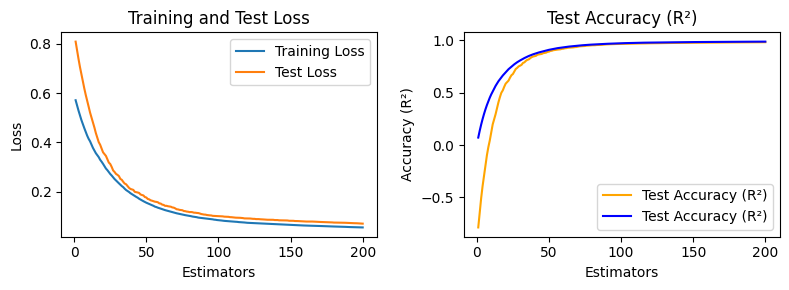

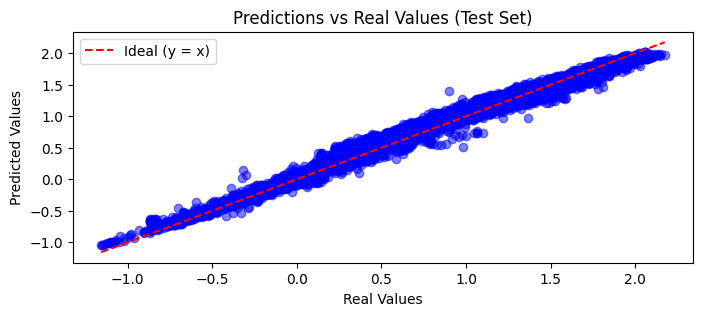

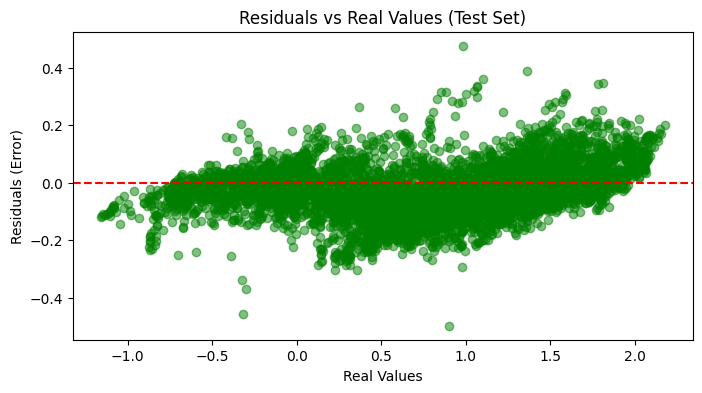

In [30]:
# Entrenar y obtener métricas
train_losses, test_losses, test_accuracies, train_accuracies = train_and_evaluate_xgboost(model, X_train, y_train, X_test, y_test, max_estimators=estimators)

# Graficar métricas
plot_training_metrics(train_losses, test_losses, test_accuracies, train_accuracies, max_estimators=estimators)

# Hacer predicciones en el conjunto de prueba
y_test_pred = model.predict(X_test)

# Graficar predicciones vs reales
plot_test_predictions(y_test, y_test_pred)

Dimensiones del DataFrame: (30912, 9)


,voltaje,corriente_carga,temperatura_aceite,temperatura_aceite_OLTC,temperatura_ambiente,temperatura_punto_caliente,temperatura_burbujeo,potencia_aparente,tap_position
timestamp,,,,,,,,,
2024-09-10 04:00:00,131.041825,739.327177,51.534286,47.685000,26.500000,56.185879,178.928398,30.745757,10
2024-09-10 04:15:00,130.693073,728.593612,53.500000,49.825000,26.650000,58.642727,178.854984,30.232734,11
2024-09-10 04:30:00,130.812457,715.310359,53.342857,50.025000,26.800000,58.308074,178.781570,29.725678,11
2024-09-10 04:45:00,130.924854,701.814300,53.185714,49.739999,26.600000,57.973421,178.411140,29.164683,11
2024-09-10 05:00:00,130.564417,688.681148,53.028571,48.650999,26.233334,57.638768,176.250397,28.610652,11


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 30912 entries, 2024-09-10 04:00:00 to 2025-07-29 03:45:00
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   voltaje                     30912 non-null  float64
 1   corriente_carga             30912 non-null  float64
 2   temperatura_aceite          30912 non-null  float64
 3   temperatura_aceite_OLTC     30912 non-null  float64
 4   temperatura_ambiente        30912 non-null  float64
 5   temperatura_punto_caliente  30912 non-null  float64
 6   temperatura_burbujeo        30912 non-null  float64
 7   potencia_aparente           30912 non-null  float64
 8   tap_position                30912 non-null  int64  
dtypes: float64(8), int64(1)
memory usage: 2.4 MB


KeyError: 'temperatura_burbujeo'

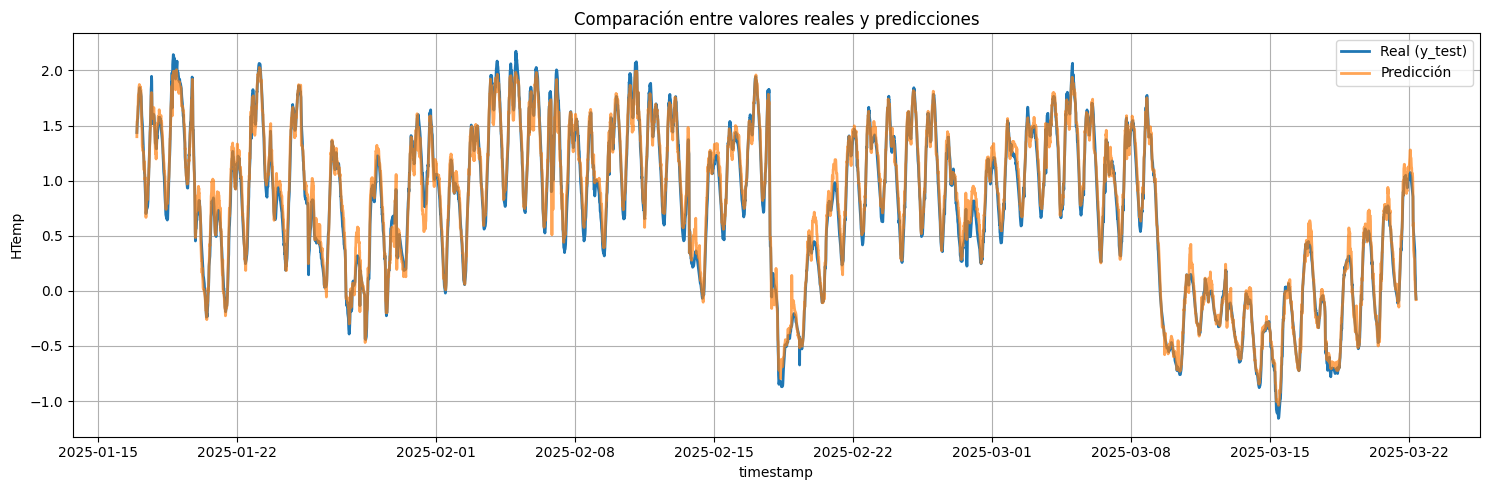

In [31]:
# Crear la figura
plt.figure(figsize=(15, 5))
plt.plot(y_test, label="Real (y_test)", linewidth=2)
plt.plot(y_test.index, y_test_pred, label="Predicción", linewidth=2, alpha=0.7)
plt.title("Comparación entre valores reales y predicciones")
plt.xlabel("timestamp")
plt.ylabel("HTemp")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [54]:
import mlflow 
from mlflow.models import infer_signature

mlflow.set_experiment("XGBoost_Experiment")
mlflow.set_tracking_uri("http://localhost:5000")  # Asegúrate de que el servidor MLflow esté corriendo

2025/08/14 15:44:22 INFO mlflow.tracking.fluent: Experiment with name 'XGBoost_Experiment' does not exist. Creating a new experiment.


In [78]:

# Start an MLflow run
with mlflow.start_run(run_name= f"Con features (sin tap) - hora"):
  # Log the hyperparameters
  mlflow.log_params(param_dist)
  # tag de mi
  mlflow.set_tag("model_type", "XGBoost")
  mlflow.set_tag("data_version", "v1.0")

  # Log the loss metric
  mlflow.log_metric("test accuracy", test_accuracies[-1])
  mlflow.log_metric("train_accuracy", train_accuracies[-1])
  mlflow.log_metric("test_loss", test_losses[-1])
  mlflow.log_metric("train_loss", train_losses[-1]) 

  # Set a tag that we can use to remind ourselves what this run was for
  mlflow.set_tag("Training and Test Info", "cambio para ver si eran los estimators que no permitian aprender al principio pero parece que no")

  # Infer the model signature
  signature = infer_signature(X_train, model.predict(X_train))

  # Log the model
  model_info = mlflow.sklearn.log_model(
      sk_model=model,
      name="xgboost_model",
      signature=signature,
      input_example=X_train,
      registered_model_name="tracking-quickstart",
  )

c:\Users\Asus TUF\Desktop\proy_ml\venv311\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
Registered model 'tracking-quickstart' already exists. Creating a new version of this model...
2025/08/14 16:15:33 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. 

🏃 View run Con features (sin tap) - hora at: http://localhost:5000/#/experiments/343652921856468742/runs/a17678d1a16e4cd192173b924517d114
🧪 View experiment at: http://localhost:5000/#/experiments/343652921856468742


Created version '6' of model 'tracking-quickstart'.


Dimensiones del DataFrame: (30912, 9)
                        voltaje  corriente_carga  temperatura_aceite  \
timestamp                                                              
2024-09-10 04:00:00  131.041825       739.327177           51.534286   
2024-09-10 04:15:00  130.693073       728.593612           53.500000   
2024-09-10 04:30:00  130.812457       715.310359           53.342857   
2024-09-10 04:45:00  130.924854       701.814300           53.185714   
2024-09-10 05:00:00  130.564417       688.681148           53.028571   

                     temperatura_aceite_OLTC  temperatura_ambiente  \
timestamp                                                            
2024-09-10 04:00:00                47.685000             26.500000   
2024-09-10 04:15:00                49.825000             26.650000   
2024-09-10 04:30:00                50.025000             26.800000   
2024-09-10 04:45:00                49.739999             26.600000   
2024-09-10 05:00:00                48

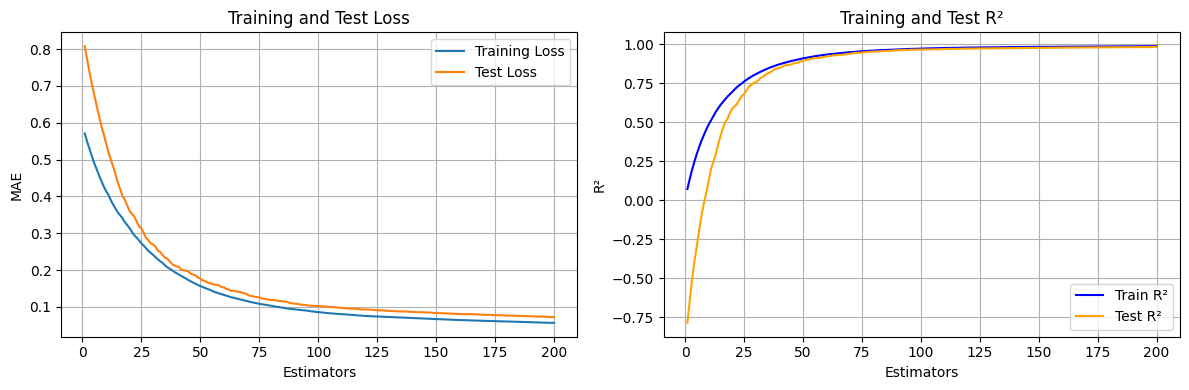

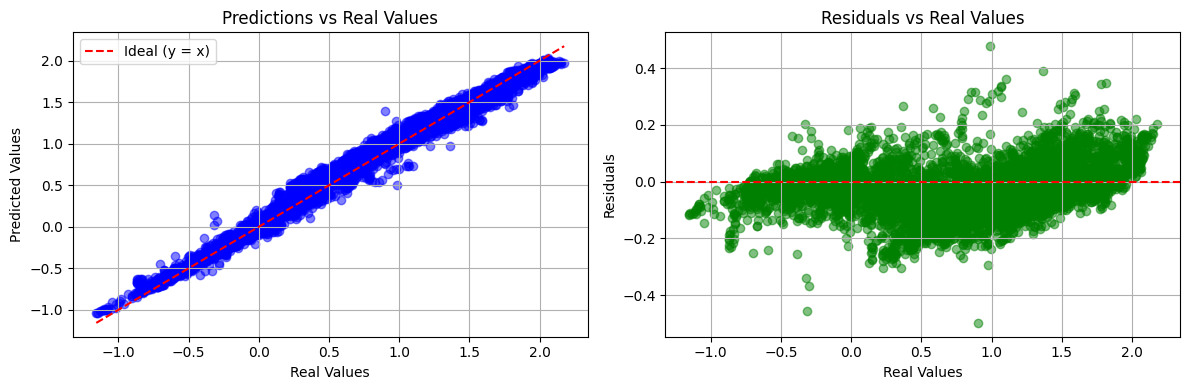

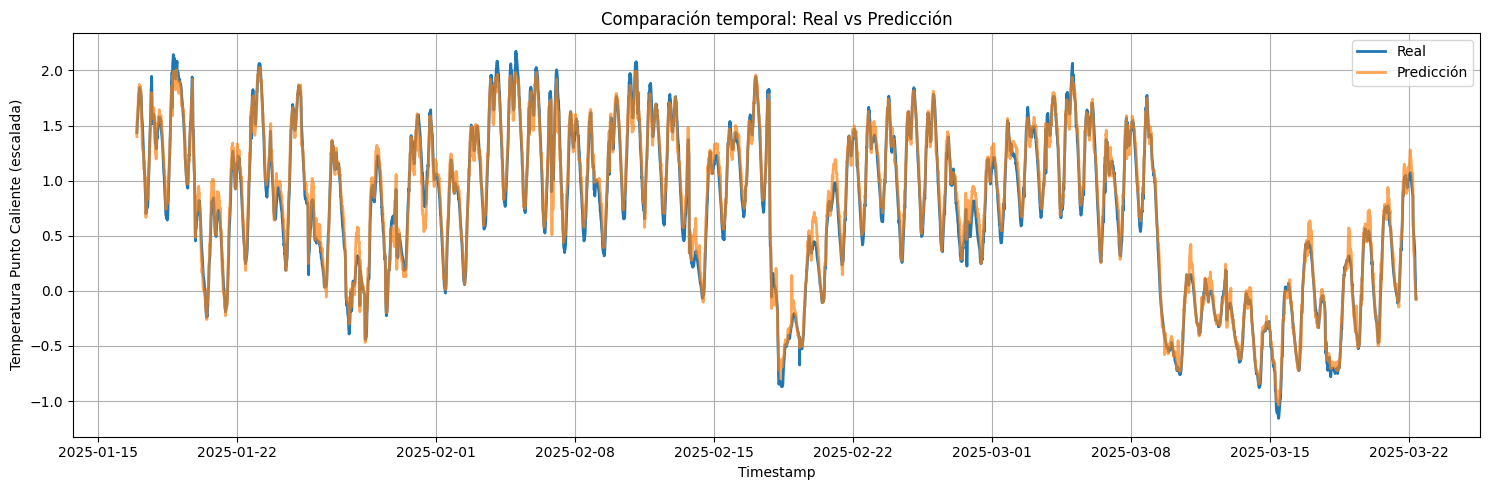


PASO 11: Métricas finales del modelo:
R² Entrenamiento: 0.9887
R² Prueba: 0.9833
MAE Entrenamiento: 0.0564
MAE Prueba: 0.0718


In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import seaborn as sns
from datetime import datetime
from sklearn.preprocessing import RobustScaler
import os
from scipy import stats
from xgboost import XGBRegressor
import xgboost as xgb
import mlflow 
from mlflow.models import infer_signature

# %%
# Configuración de rutas
BASE_DIR = os.path.abspath(os.path.join(os.path.dirname('__file__'), "..", ".."))
SILVER_DIR = os.path.join(BASE_DIR, "data", "capa_silver")
SILVER_FILE_PATH = os.path.join(SILVER_DIR, "silver_data.parquet")

VARIABLES_CONTINUAS = [
    "voltaje",
    "corriente_carga",
    "temperatura_aceite",
    "temperatura_aceite_OLTC",
    "temperatura_ambiente",
    "temperatura_punto_caliente",
    "temperatura_burbujeo",
    "potencia_aparente",
]
VARIABLES_DISCRETAS = [
    "tap_position"
]

# %%
# Cargar datos
try:
    df_gold = pd.read_parquet(SILVER_FILE_PATH)
    print(f"Dimensiones del DataFrame: {df_gold.shape}")
    print(df_gold.head())
    print("\nInformacion del DataFrame:")
    df_gold.info()
except Exception as e:
    print(f"Ocurrio un error al cargar los datos Silver: {e}")

# %%
class BoxCoxTransformer:
    """
    Aplica Box–Cox a columnas continuas y positivas.
    - Si la columna tiene valores <= 0, aplica un shift: x' = x + |min| + eps.
    - Guarda lambda y shift por columna para poder invertir.
    """

    def __init__(self, eps=1e-6):
        self.eps = eps
        self.lambdas_ = {}  # {col: lambda}
        self.shifts_  = {}  # {col: shift añadido}

    def fit(self, df: pd.DataFrame, cols: list):
        """Ajusta los parámetros SOLO con datos de entrenamiento"""
        for col in cols:
            x = df[col].astype(float).to_numpy()

            # Shift si hay valores <= 0
            shift = 0.0
            x_min = np.nanmin(x)
            if not np.isfinite(x_min):
                raise ValueError(f"{col}: todos los valores son NaN/inf; revise la columna.")
            if x_min <= 0:
                shift = -x_min + self.eps
                x = x + shift

            # Relleno temporal de NaNs para el ajuste del lambda
            nan_mask = np.isnan(x)
            if nan_mask.any():
                mean_val = np.nanmean(x)
                x_for_fit = x.copy()
                x_for_fit[nan_mask] = mean_val
            else:
                x_for_fit = x

            # Solo ajustar lambda, NO transformar aún
            _, lam = stats.boxcox(x_for_fit)

            # Guardar parámetros
            self.lambdas_[col] = lam
            self.shifts_[col] = shift

    def transform(self, df: pd.DataFrame, cols: list) -> pd.DataFrame:
        """Aplica transformación usando parámetros ya ajustados"""
        df_out = df.copy()
        for col in cols:
            if col not in self.lambdas_:
                raise ValueError(f"No hay lambda para la columna '{col}'. Ejecute fit primero.")
            
            x = df_out[col].astype(float).to_numpy()
            shift = self.shifts_[col]
            lam = self.lambdas_[col]

            # Aplicar shift si es necesario
            if shift > 0:
                x = x + shift

            # Aplicar transformación Box-Cox
            nan_mask = np.isnan(x)
            if lam == 0:
                x_bc = np.log(x)
            else:
                x_bc = (np.power(x, lam) - 1) / lam
            
            x_bc[nan_mask] = np.nan
            df_out[col] = x_bc

        return df_out

    def fit_transform(self, df: pd.DataFrame, cols: list) -> pd.DataFrame:
        """Fit + transform en un solo paso (solo para entrenamiento)"""
        self.fit(df, cols)
        return self.transform(df, cols)

    def inverse_transform(self, df: pd.DataFrame, cols: list) -> pd.DataFrame:
        """Invierte la transformación"""
        df_inv = df.copy()
        for col in cols:
            if col not in self.lambdas_:
                raise ValueError(f"No hay lambda para la columna '{col}'. Ejecute fit primero.")
            lam = self.lambdas_[col]
            shift = self.shifts_.get(col, 0.0)

            y = df_inv[col].astype(float).to_numpy()
            nan_mask = np.isnan(y)

            # Inversa de Box–Cox
            if lam == 0:
                x = np.exp(y)
            else:
                x = np.power(lam * y + 1.0, 1.0 / lam)

            # Quitar shift
            x = x - shift
            x[nan_mask] = np.nan
            df_inv[col] = x
        return df_inv

# %%
def create_features(df):
    """Crea features derivadas"""
    df_copy = df.copy()
    df_copy["gradiente_termico"] = df_copy["temperatura_aceite"] - df_copy["temperatura_ambiente"]
    df_copy["hour"] = df_copy.index.hour
    df_copy["dia_semana"] = df_copy.index.dayofweek
    df_copy["mes"] = df_copy.index.month
    df_copy["is_weekend"] = (df_copy.index.dayofweek >= 5).astype(int)
    return df_copy

# %%
# PASO 1: División temporal SIN transformaciones (evitar data leakage)
print("PASO 1: División temporal de datos...")
df_clean = df_gold.dropna()  # Solo eliminar NaNs una vez al principio

total_len = len(df_clean)
train_start = int(total_len * 0.4)
train_end = int(total_len * 0.6)

# Test: 20% del medio
df_test_raw = df_clean[train_start:train_end]

# Train: 40% del inicio + 40% del final
df_train_raw = pd.concat([df_clean[:train_start], df_clean[train_end:]], axis=0)

print(f"Datos de entrenamiento: {df_train_raw.shape}")
print(f"Datos de prueba: {df_test_raw.shape}")

# %%
# PASO 2: BoxCox - Ajustar SOLO con datos de entrenamiento
print("\nPASO 2: Aplicando transformación BoxCox...")
cols_bc = ["corriente_carga", "temperatura_burbujeo", "potencia_aparente"]

bc = BoxCoxTransformer(eps=1e-6)

# Ajustar SOLO con datos de entrenamiento
bc.fit(df_train_raw, cols_bc)

# Aplicar transformación a ambos conjuntos
df_train_bc = bc.transform(df_train_raw, cols_bc)
df_test_bc = bc.transform(df_test_raw, cols_bc)

print("Parámetros BoxCox ajustados:")
for col in cols_bc:
    print(f"{col}: lambda={bc.lambdas_[col]:.4f}, shift={bc.shifts_[col]:.4f}")

# %%
# PASO 3: Feature Engineering por separado
print("\nPASO 3: Creando features derivadas...")
df_train_features = create_features(df_train_bc)
df_test_features = create_features(df_test_bc)

# %%
# PASO 4: Eliminar columnas multicolineales
print("\nPASO 4: Eliminando columnas multicolineales...")
cols_to_drop_for_multicollinearity = [
    'corriente_carga',
    'temperatura_aceite',
    'temperatura_aceite_OLTC',
    'temperatura_burbujeo'
]

existing_cols_to_drop = [col for col in cols_to_drop_for_multicollinearity if col in df_train_features.columns]

df_train_clean = df_train_features.drop(columns=existing_cols_to_drop)
df_test_clean = df_test_features.drop(columns=existing_cols_to_drop)

print(f"Columnas eliminadas: {existing_cols_to_drop}")

# %%
# PASO 5: Escalado - Ajustar SOLO con datos de entrenamiento
print("\nPASO 5: Aplicando escalado RobustScaler...")
columnas_a_escalar = [
    'voltaje', 'temperatura_ambiente', 'temperatura_punto_caliente',
    'potencia_aparente', 'gradiente_termico', 'hour', 'dia_semana', 'mes', 'is_weekend'
]

scaler = RobustScaler()

# Ajustar SOLO con datos de entrenamiento
scaler.fit(df_train_clean[columnas_a_escalar])

# Aplicar transformación a ambos conjuntos
df_train_scaled = df_train_clean.copy()
df_test_scaled = df_test_clean.copy()

df_train_scaled[columnas_a_escalar] = scaler.transform(df_train_clean[columnas_a_escalar])
df_test_scaled[columnas_a_escalar] = scaler.transform(df_test_clean[columnas_a_escalar])

print("Escalado completado.")

# %%
# PASO 6: Preparar variables para modelado
print("\nPASO 6: Preparando variables X e y...")
X_train = df_train_scaled.drop(columns=['temperatura_punto_caliente'])
y_train = df_train_scaled['temperatura_punto_caliente']
X_test = df_test_scaled.drop(columns=['temperatura_punto_caliente'])
y_test = df_test_scaled['temperatura_punto_caliente']

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Features: {list(X_train.columns)}")

# %%
# PASO 7: Configuración del modelo
print("\nPASO 7: Configurando modelo XGBoost...")
estimators = 200

params = { 
    "n_estimators": estimators,
    "learning_rate": 0.05,
    "gamma": 0.3,
    "min_child_weight": 5,
    "max_depth": 2,
    "subsample": 0.7,
    "colsample_bytree": 0.9,
    "objective": 'reg:squarederror',
    "random_state": 42,
    "n_jobs": 3
}

model = xgb.XGBRegressor(**params)
print("Parámetros del modelo:", model.get_params())

# %%
# PASO 8: Funciones de entrenamiento y evaluación
def train_and_evaluate_xgboost(model, X_train, y_train, X_test, y_test, max_estimators=200):
    """Entrena y evalúa XGBoost con diferentes números de estimadores"""
    train_accuracies = []
    train_losses = []
    test_losses = []
    test_accuracies = []

    for n_estimators in range(1, max_estimators + 1):
        model.set_params(n_estimators=n_estimators)
        model.fit(X_train, y_train)

        # Predicciones
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        # Calcular métricas
        train_accuracy = r2_score(y_train, y_train_pred)
        train_loss = mean_absolute_error(y_train, y_train_pred)
        test_loss = mean_absolute_error(y_test, y_test_pred)
        test_accuracy = r2_score(y_test, y_test_pred)

        # Guardar métricas
        train_accuracies.append(train_accuracy)
        train_losses.append(train_loss)
        test_losses.append(test_loss)
        test_accuracies.append(test_accuracy)

        # Imprimir progreso cada 10 iteraciones
        if n_estimators % 10 == 0 or n_estimators == 1:
            print(f"Estimators: {n_estimators}/{max_estimators}.. Tr MAE: {train_loss:.3f}.. Test MAE: {test_loss:.3f}.. tr R²: {train_accuracy:.3f}.. Test R²: {test_accuracy:.3f}")

    return train_losses, test_losses, test_accuracies, train_accuracies

def plot_training_metrics(train_losses, test_losses, test_accuracies, train_accuracies, max_estimators=200):
    """Grafica métricas de entrenamiento"""
    plt.figure(figsize=(12, 4))

    # Gráfica de pérdida
    plt.subplot(1, 2, 1)
    plt.plot(range(1, max_estimators + 1), train_losses, label='Training Loss')
    plt.plot(range(1, max_estimators + 1), test_losses, label='Test Loss')
    plt.xlabel("Estimators")
    plt.ylabel("MAE")
    plt.legend()
    plt.title("Training and Test Loss")
    plt.grid(True)

    # Gráfica de precisión (R²)
    plt.subplot(1, 2, 2)
    plt.plot(range(1, max_estimators + 1), train_accuracies, label='Train R²', color='blue')
    plt.plot(range(1, max_estimators + 1), test_accuracies, label='Test R²', color='orange')
    plt.xlabel("Estimators")
    plt.ylabel("R²")
    plt.legend()
    plt.title("Training and Test R²")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

def plot_test_predictions(y_test, y_test_pred):
    """Grafica predicciones vs valores reales"""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    # Scatter plot
    axes[0].scatter(y_test, y_test_pred, color='blue', alpha=0.5)
    axes[0].plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Ideal (y = x)')
    axes[0].set_xlabel("Real Values")
    axes[0].set_ylabel("Predicted Values")
    axes[0].set_title("Predictions vs Real Values")
    axes[0].legend()
    axes[0].grid(True)

    # Residuals plot
    residuals = y_test - y_test_pred
    axes[1].scatter(y_test, residuals, color='green', alpha=0.5)
    axes[1].axhline(y=0, color='red', linestyle='--')
    axes[1].set_xlabel("Real Values")
    axes[1].set_ylabel("Residuals")
    axes[1].set_title("Residuals vs Real Values")
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.show()

# %%
# PASO 9: Entrenamiento y evaluación
print("\nPASO 9: Entrenando modelo...")
train_losses, test_losses, test_accuracies, train_accuracies = train_and_evaluate_xgboost(
    model, X_train, y_train, X_test, y_test, max_estimators=estimators
)

# %%
# PASO 10: Visualización de resultados
print("\nPASO 10: Visualizando resultados...")

# Gráficas de métricas
plot_training_metrics(train_losses, test_losses, test_accuracies, train_accuracies, max_estimators=estimators)

# Predicciones finales
y_test_pred = model.predict(X_test)
plot_test_predictions(y_test, y_test_pred)

# Serie temporal
plt.figure(figsize=(15, 5))
plt.plot(y_test.index, y_test, label="Real", linewidth=2)
plt.plot(y_test.index, y_test_pred, label="Predicción", linewidth=2, alpha=0.7)
plt.title("Comparación temporal: Real vs Predicción")
plt.xlabel("Timestamp")
plt.ylabel("Temperatura Punto Caliente (escalada)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# %%
# PASO 11: Métricas finales
print("\nPASO 11: Métricas finales del modelo:")
final_train_r2 = train_accuracies[-1]
final_test_r2 = test_accuracies[-1]
final_train_mae = train_losses[-1]
final_test_mae = test_losses[-1]

print(f"R² Entrenamiento: {final_train_r2:.4f}")
print(f"R² Prueba: {final_test_r2:.4f}")
print(f"MAE Entrenamiento: {final_train_mae:.4f}")
print(f"MAE Prueba: {final_test_mae:.4f}")
